In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pprint
import matplotlib.pyplot as plt
import plotting as plotting
from solvers import SmdpForwardSearchSolver, SmdpMctsSolver, DiscreteTimeIpSolver, RuleBasedSolver
from problem import State, Action, Request, ServiceWindow, PntSchedulingProblem, reset_id_counters
pp = pprint.PrettyPrinter()
figures_path = "../figures/AA229/"


# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Toy Problem

[Request(user_id=0,
         start=0.0,
         end=10.0,
         duration=2.0,
         priority=1,
         arrival=0.0,
         id=0),
 Request(user_id=1,
         start=0.0,
         end=10.0,
         duration=2.0,
         priority=1,
         arrival=0.0,
         id=1),
 Request(user_id=1,
         start=0.0,
         end=10.0,
         duration=3.0,
         priority=1,
         arrival=3.0,
         id=2),
 Request(user_id=2,
         start=0.0,
         end=10.0,
         duration=2.0,
         priority=1,
         arrival=0.0,
         id=3),
 Request(user_id=3,
         start=0.0,
         end=10.0,
         duration=2.0,
         priority=1,
         arrival=3.0,
         id=4)]
[Request(user_id=0,
         start=0.0,
         end=10.0,
         duration=2.0,
         priority=1,
         arrival=0.0,
         id=0),
 Request(user_id=1,
         start=0.0,
         end=10.0,
         duration=2.0,
         priority=1,
         arrival=0.0,
         id=1),
 Request(user

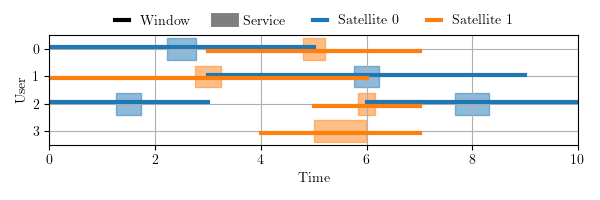

In [303]:
reset_id_counters()
requests = [
    Request(id=0, user_id=0, start=0.0, end=10.0, duration=2.0, arrival=0.0),
    Request(id=1, user_id=1, start=0.0, end=10.0, duration=2.0, arrival=0.0),
    Request(id=2, user_id=1, start=0.0, end=10.0, duration=3.0, arrival=3.0),
    Request(id=3, user_id=2, start=0.0, end=10.0, duration=2.0, arrival=0.0),
    Request(id=4, user_id=3, start=0.0, end=10.0, duration=2.0, arrival=3.0),
]
pp.pprint(requests)
N_req = len(requests)
request_dict = {r.id: r for r in requests}

service_windows = [
    # Satellite 0
    ServiceWindow(user_id=0, satellite_id=0, start=0.0, end=5.0),
    ServiceWindow(user_id=1, satellite_id=0, start=3.0, end=9.0),
    ServiceWindow(user_id=2, satellite_id=0, start=0.0, end=3.0),
    ServiceWindow(user_id=2, satellite_id=0, start=6.0, end=10.0),
    # ServiceWindow(user_id=3, satellite_id=0, start=6, end=10),
    # Satellite 1
    ServiceWindow(user_id=0, satellite_id=1, start=3.0, end=7.0),
    ServiceWindow(user_id=1, satellite_id=1, start=0.0, end=6.0),
    ServiceWindow(user_id=2, satellite_id=1, start=5.0, end=7.0),
    ServiceWindow(user_id=3, satellite_id=1, start=4.0, end=7.0),
]
pp.pprint(requests)
N_win = len(service_windows)
N_sat = 2

transition_times = np.ones((len(service_windows), len(service_windows)))
transition_times = np.ones((N_sat, N_req, N_req))
for i in range(N_sat):
    transition_times[i, np.diag_indices(N_req)] = 0
transition_times[0, :] = 0
transition_times[:, 0] = 0
data_gen_func = lambda ts, te: -0.5 * (te - ts)
energy_gen_func = lambda ts, te: 0.5 * (te - ts)


time_step = 1
CN0 = np.ones((2, len(requests) - 1, 10 * time_step))

problem = PntSchedulingProblem(
    time_step=time_step,
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    CN0=CN0,
    max_energy=15,
    min_energy=2,
    max_data=15,
    min_data=2,
    payload_data_gen=1,
    payload_power_gen=-1,
    energy_gen_func=energy_gen_func,
    data_gen_func=data_gen_func,
)

fig, ax = plt.subplots(1, 1, figsize=(6, 2))
plotting.plot_requests_service_windows(requests, service_windows, ax=ax)
plt.tight_layout()

# No constraints

In [309]:
# Forward search
d = 8
gamma = 0.7
N_max = 5
d_min = 1
problem.set_current_time(0)
problem.set_current_policy(None)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)
# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 3.36
Percentage of requests served:
[100.0, 100.0, nan, 100.0, nan]
Total: 3.36


Total reward: 3.36


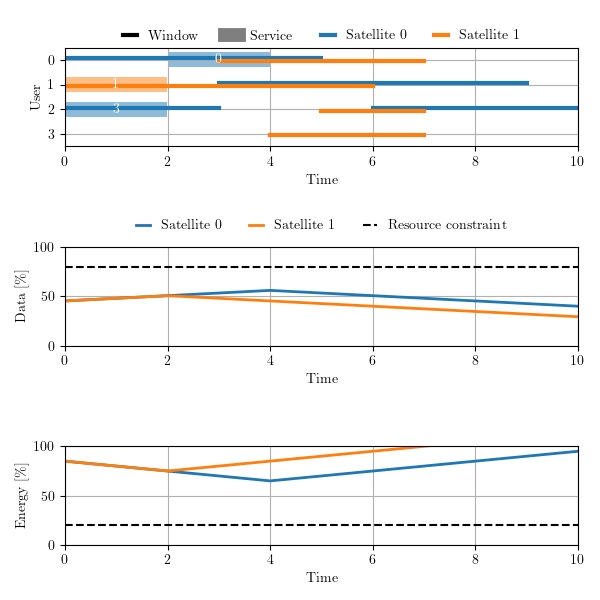

In [310]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [311]:
old_policy = policy
arrival_times = sorted(list(set([r.arrival for r in requests])))
arrival_times


[0.0, 3.0]

In [312]:
# Forward search
d = 6
gamma = 0.7
N_max = 5
d_min = 10
problem.set_current_time(3)
problem.set_current_policy(old_policy)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)
# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 0.49
Percentage of requests served:
[100.0, 100.0, 100.0, 100.0, 50.0]
Total: 0.49


Total reward: 0.49


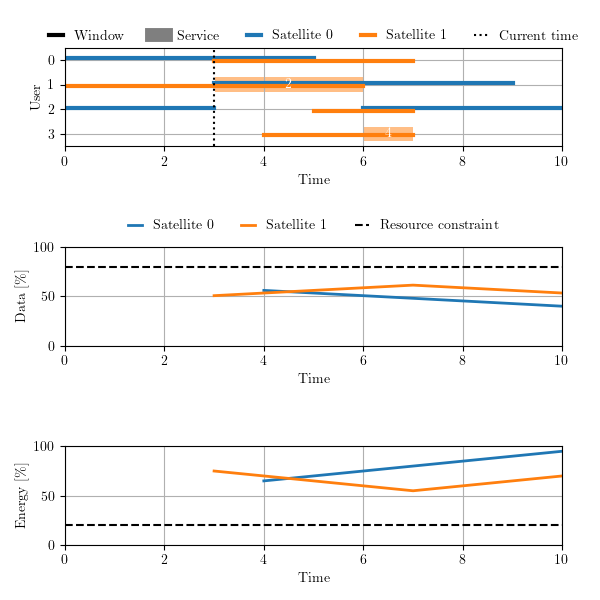

In [313]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=axs[0], current_time=3
)
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [314]:
idx = problem.get_current_policy_index()
merged_policy = old_policy[:idx] + policy

Total reward: 3.85


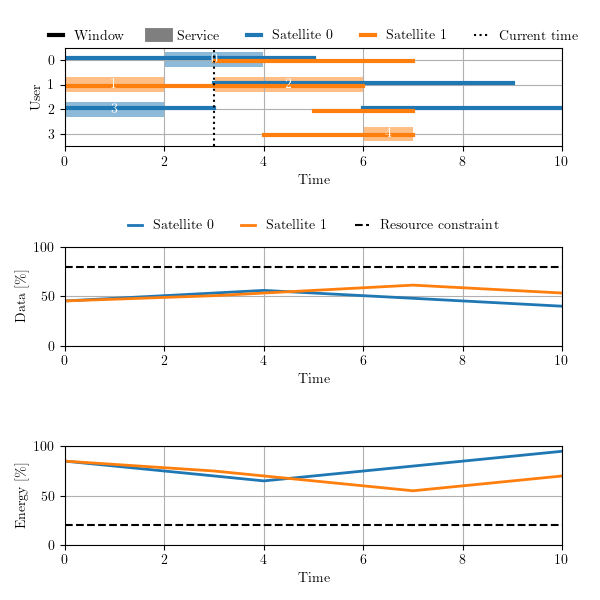

In [315]:
policy = merged_policy
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=axs[0], current_time=problem.current_time
)
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

# Constraints

In [316]:
# Forward search

# Parameters
d = 5
gamma = 0.7
N_max = 5
d_min = 2

# Config
problem.set_current_time(0)
problem.set_current_policy(None)

# Solve
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)

# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 3.36
Percentage of requests served:
[100.0, 100.0, nan, 100.0, nan]
Total: 3.36


In [317]:
actions = [
    Action(satellite_id=0, request=requests[0], start=0.0, duration=2.0),
    Action(satellite_id=1, request=requests[1], start=0.0, duration=2.0),
    Action(satellite_id=0, request=requests[3], start=6.0, duration=2.0),
]

s = problem.initial_state()
policy = list[tuple[State, Action]]()
for a in actions:
    policy.append((s, a))
    s = problem.transition_function(s, a)
policy.append((s, None))

Total reward: 2.89


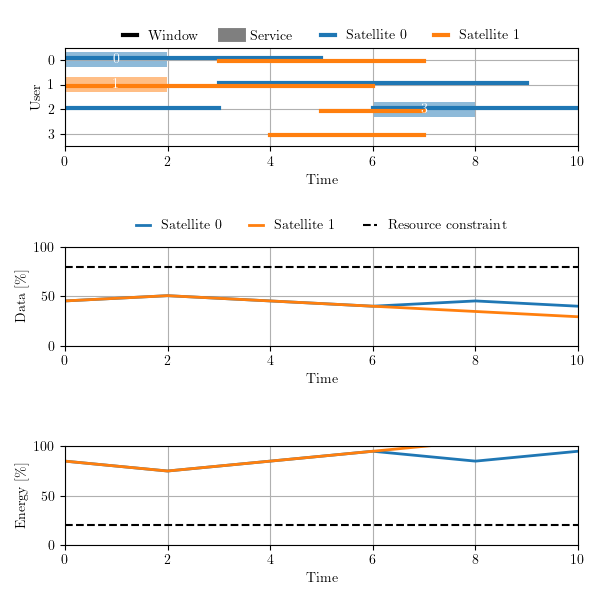

In [319]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [320]:
# Minimum energy and maximum data at start time of a given action
required_resources = dict[Action, tuple[float, float]]()
for sat_id in range(N_sat):
    actions = [
        a
        for s, a in policy[::-1]
        if a is not None and a.request is not None and a.satellite_id == sat_id
    ]
    e = problem.min_energy
    d = problem.max_data
    a = actions[0]
    t_prev = a.start + a.duration
    for a in actions:
        # Energy and data from start to end of action
        e += problem.payload_data_gen * a.duration
        d -= problem.payload_power_gen * a.duration

        # Energy and data from start of action to start of the next
        e -= problem.data_gen_func(a.start, t_prev)
        d += problem.energy_gen_func(a.start, t_prev)

        required_resources[a] = (e, d)
        t_prev = a.start

required_resources

{Action(sat=0, usr=2, req=3, start=6.00, dur=2.00): (5.0, 18.0),
 Action(sat=0, usr=0, req=0, start=0.00, dur=2.00): (10.0, 23.0),
 Action(sat=1, usr=1, req=1, start=0.00, dur=2.00): (5.0, 18.0)}

In [321]:
old_policy = policy
arrival_times = sorted(list(set([r.arrival for r in requests])))
arrival_times


[0.0, 3.0]

In [322]:
# Config
problem.set_current_time(3)
problem.set_current_policy(old_policy, constrained=True)
problem.initial_state()

State(t=[3 3], d=[9.5 9.5], e=[7.5 7.5], req=[2.0, 2.0, 0.0, 2.0, 0.0])

Total reward: 2.89


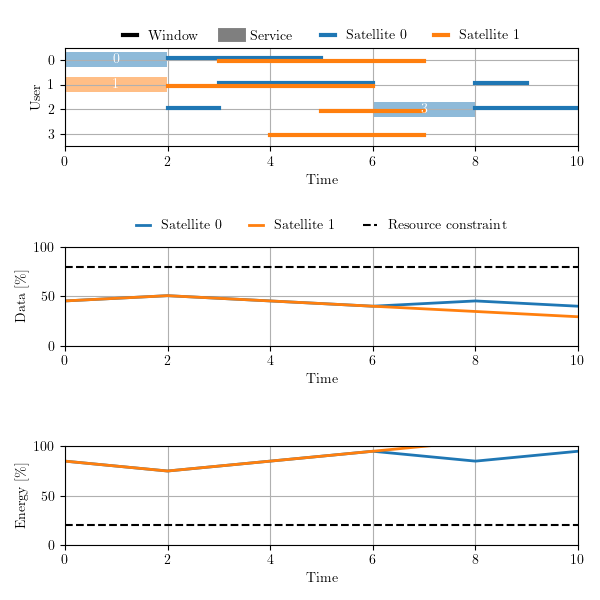

: 

In [324]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, problem.constrained_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [276]:
# Forward search
d = 6
gamma = 0.7
N_max = 5
d_min = 10
problem.set_current_time(3)
problem.set_current_policy(old_policy)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)
# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 0.49
Percentage of requests served:
[100.0, 100.0, 100.0, 100.0, 50.0]
Total: 0.49


Total reward: 0.49


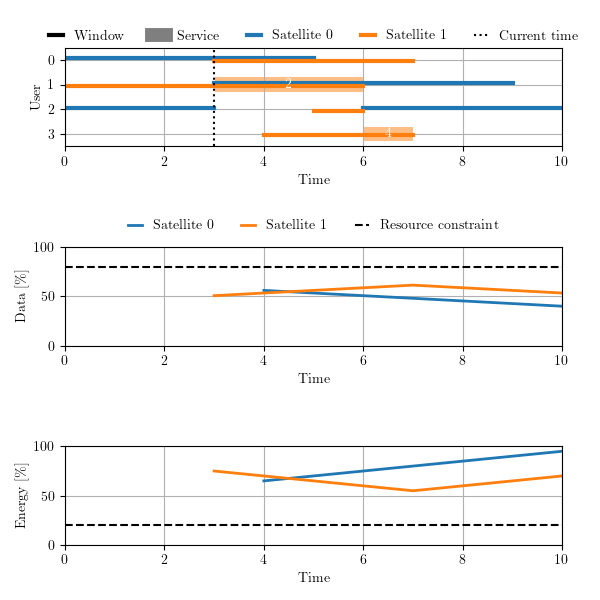

In [277]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=axs[0], current_time=3
)
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [134]:
# MCTS
d = 5
gamma = 0.9
n = int(1e3)
c = 10
N_max = 5
d_min = 1
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, n=n, c=c, N_max=N_max, d_min=d_min)
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

AttributeError: 'State' object has no attribute 'time'

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Apr 04 02:23:38 PM: Your problem has 80 variables, 291 constraints, and 0 parameters.
(CVXPY) Apr 04 02:23:38 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 04 02:23:38 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 04 02:23:38 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 04 02:23:38 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 04 02:23:38 PM: Compiling problem (target solver=GUROBI).


(CVXPY) Apr 04 02:23:38 PM: Applying reduction QpMatrixStuffing
(CVXPY) Apr 04 02:23:38 PM: Applying reduction GUROBI
(CVXPY) Apr 04 02:23:38 PM: Finished problem compilation (took 6.473e-02 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Apr 04 02:23:38 PM: Invoking solver GUROBI  to obtain a solution.
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-11
Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (mac64[arm] - Darwin 23.3.0 23D60)

CPU model: Apple M3 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 574 rows, 152 columns and 1848 nonzeros
Model fingerprint: 0x1f80aef1
Variable types: 72 continuous, 80 integer (80 binary)
Coefficient statistics:
  

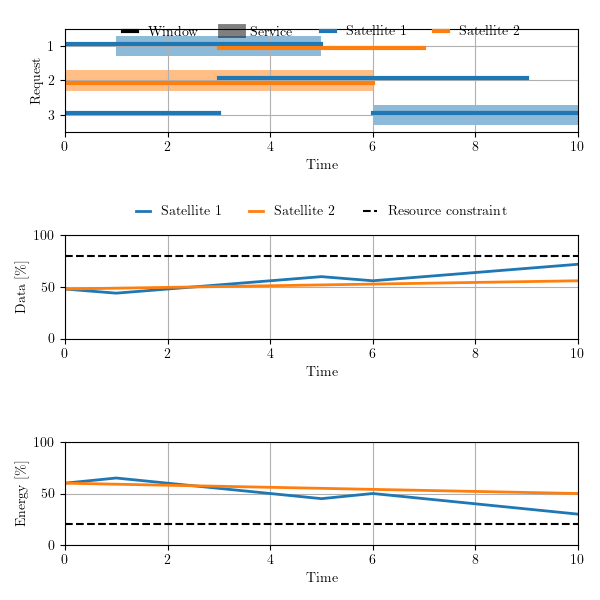

In [ ]:
# IP
solver = DiscreteTimeIpSolver(problem)
policy = solver.solve(s, time_step_factor=1)
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()